# Customer Churn Analysis
## Task 04 — Segmentation and Recommendation Model

### Objective

The objective of this task is to segment customers based on their
characteristics, identify customers who may be at higher risk of churn,
and generate explainable recommendations for customer retention.

The model will use customer characteristics such as:

- Contract type
- Tenure
- Monthly charges
- Payment method
- Subscription type
- Support ticket volume

### Main Goals

1. Create meaningful customer segments.
2. Calculate an explainable churn-risk score.
3. Categorize customers into Low, Medium, and High risk.
4. Identify the factors contributing to customer risk.
5. Generate actionable retention recommendations.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from IPython.display import display

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

In [2]:
from google.colab import files

uploaded = files.upload()

Saving customer_churn_task03_dashboard.csv to customer_churn_task03_dashboard.csv


In [3]:
df = pd.read_csv("customer_churn_task03_dashboard.csv")

print("Dataset shape:", df.shape)

df

Dataset shape: (15, 12)


,CustomerID,Gender,Age,TenureMonths,SubscriptionType,MonthlyCharges,TotalCharges,ContractType,SupportTickets,PaymentMethod,Churn,TenureGroup
0,CUST-1001,Female,34,12,Basic,49.99,599.88,Month-to-Month,3,Credit Card,Yes,0-12 months
1,CUST-1002,Male,45,24,Pro,79.99,1919.76,One Year,1,Bank Transfer,No,13-24 months
2,CUST-1003,Female,29,6,Basic,49.99,299.94,Month-to-Month,5,UPI,Yes,0-12 months
3,CUST-1004,Male,52,36,Enterprise,149.99,5399.64,Two Year,0,Credit Card,No,25-36 months
4,CUST-1005,Female,41,8,Pro,79.99,639.92,Month-to-Month,4,Debit Card,Yes,0-12 months
5,CUST-1006,Male,31,18,Basic,49.99,899.82,One Year,2,UPI,No,13-24 months
6,CUST-1007,Female,23,3,Basic,49.99,149.97,Month-to-Month,6,Credit Card,Yes,0-12 months
7,CUST-1008,Male,60,48,Enterprise,149.99,7199.52,Two Year,1,Bank Transfer,No,37+ months
8,CUST-1009,Female,38,15,Pro,79.99,1199.85,One Year,2,Credit Card,No,13-24 months
9,CUST-1010,Male,27,4,Basic,49.99,199.96,Month-to-Month,4,UPI,Yes,0-12 months


In [4]:
df.head()

,CustomerID,Gender,Age,TenureMonths,SubscriptionType,MonthlyCharges,TotalCharges,ContractType,SupportTickets,PaymentMethod,Churn,TenureGroup
0,CUST-1001,Female,34,12,Basic,49.99,599.88,Month-to-Month,3,Credit Card,Yes,0-12 months
1,CUST-1002,Male,45,24,Pro,79.99,1919.76,One Year,1,Bank Transfer,No,13-24 months
2,CUST-1003,Female,29,6,Basic,49.99,299.94,Month-to-Month,5,UPI,Yes,0-12 months
3,CUST-1004,Male,52,36,Enterprise,149.99,5399.64,Two Year,0,Credit Card,No,25-36 months
4,CUST-1005,Female,41,8,Pro,79.99,639.92,Month-to-Month,4,Debit Card,Yes,0-12 months


In [5]:
df.tail()

,CustomerID,Gender,Age,TenureMonths,SubscriptionType,MonthlyCharges,TotalCharges,ContractType,SupportTickets,PaymentMethod,Churn,TenureGroup
10,CUST-1011,Female,49,30,Enterprise,149.99,4499.70,Two Year,0,Credit Card,No,25-36 months
11,CUST-1012,Male,33,14,Pro,79.99,1119.86,Month-to-Month,3,Debit Card,Yes,13-24 months
12,CUST-1013,Female,55,22,Basic,49.99,1099.78,One Year,1,Bank Transfer,No,13-24 months
13,CUST-1014,Male,26,2,Basic,49.99,99.98,Month-to-Month,5,UPI,Yes,0-12 months
14,CUST-1015,Female,43,40,Enterprise,149.99,5999.60,Two Year,1,Credit Card,No,37+ months


In [6]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (15, 12)

Missing Values:
CustomerID          0
Gender              0
Age                 0
TenureMonths        0
SubscriptionType    0
MonthlyCharges      0
TotalCharges        0
ContractType        0
SupportTickets      0
PaymentMethod       0
Churn               0
TenureGroup         0
dtype: int64

Duplicate Rows: 0


In [7]:
print("Available columns:")
print(df.columns.tolist())

Available columns:
['CustomerID', 'Gender', 'Age', 'TenureMonths', 'SubscriptionType', 'MonthlyCharges', 'TotalCharges', 'ContractType', 'SupportTickets', 'PaymentMethod', 'Churn', 'TenureGroup']


Customer Segmentation

Customer segmentation divides customers into groups with similar
characteristics.

For this project, we will use behavioral and financial variables:

- Age
- TenureMonths
- MonthlyCharges
- SupportTickets

These variables help identify customers with similar engagement,
tenure, spending, and support requirements.

We will use K-Means clustering to create customer segments.

### Why K-Means?

K-Means is a simple and widely used unsupervised learning algorithm
that groups customers based on similarity without requiring predefined
customer labels.

In [8]:
segment_features = [
    "Age",
    "TenureMonths",
    "MonthlyCharges",
    "SupportTickets"
]

X_segment = df[segment_features].copy()

X_segment.head()

,Age,TenureMonths,MonthlyCharges,SupportTickets
0,34,12,49.99,3
1,45,24,79.99,1
2,29,6,49.99,5
3,52,36,149.99,0
4,41,8,79.99,4


In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_segment)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (15, 4)


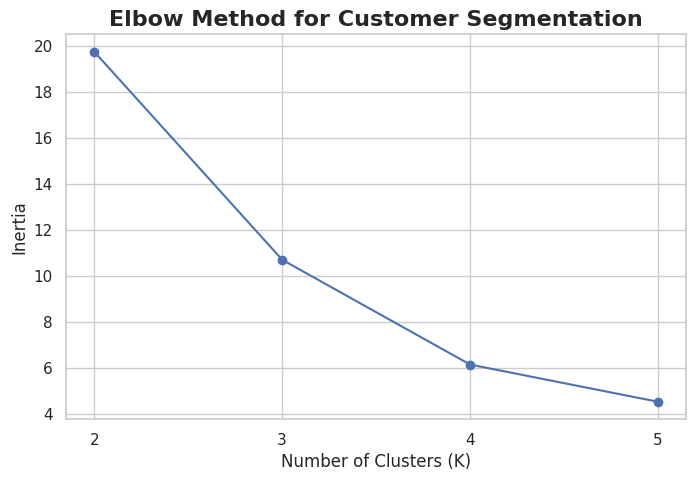

In [10]:
inertia = []

K_range = range(2, 6)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(
    list(K_range),
    inertia,
    marker="o"
)

plt.title(
    "Elbow Method for Customer Segmentation",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.xticks(list(K_range))

plt.show()

In [11]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Segment"] = kmeans.fit_predict(X_scaled)

df["Segment"].value_counts().sort_index()

,count
Segment,
0,4
1,4
2,7


In [12]:
segment_profile = df.groupby("Segment").agg({
    "Age": "mean",
    "TenureMonths": "mean",
    "MonthlyCharges": "mean",
    "SupportTickets": "mean",
    "Churn": lambda x: (x == "Yes").mean() * 100
}).round(2)

segment_profile

,Age,TenureMonths,MonthlyCharges,SupportTickets,Churn
Segment,,,,,
0,26.25,3.75,49.99,5.00,100.00
1,51.00,38.50,149.99,0.50,0.00
2,39.57,16.14,67.13,2.29,42.86


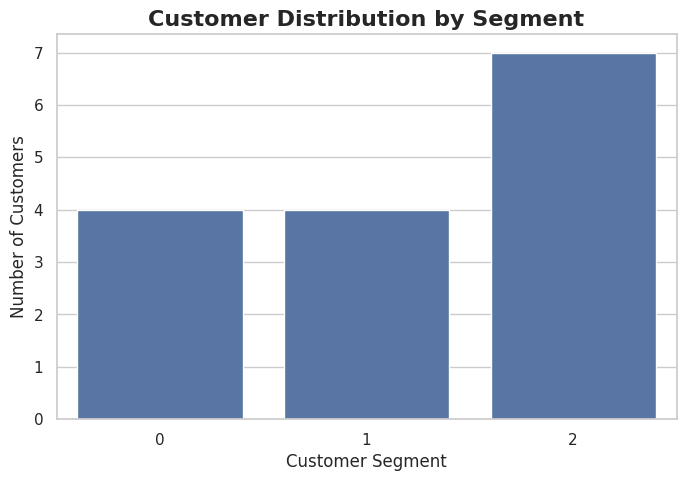

In [13]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Segment"
)

plt.title(
    "Customer Distribution by Segment",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.show()

In [14]:
segment_churn = (
    df.groupby("Segment")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

segment_churn

,Segment,ChurnRate
0,0,100.000000
1,1,0.000000
2,2,42.857143


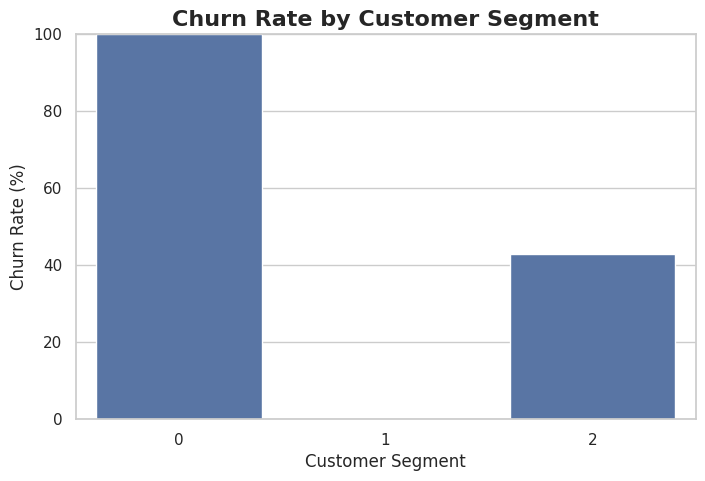

In [15]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=segment_churn,
    x="Segment",
    y="ChurnRate"
)

plt.title(
    "Churn Rate by Customer Segment",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Segment")
plt.ylabel("Churn Rate (%)")

plt.ylim(0, 100)

plt.show()

In [16]:
print(segment_profile)

           Age  TenureMonths  MonthlyCharges  SupportTickets   Churn
Segment                                                             
0        26.25          3.75           49.99            5.00  100.00
1        51.00         38.50          149.99            0.50    0.00
2        39.57         16.14           67.13            2.29   42.86


In [17]:
segment_names = {
    0: "Established Customers",
    1: "New / Low Engagement",
    2: "High Engagement / High Support"
}

df["SegmentName"] = df["Segment"].map(segment_names)

df[[
    "CustomerID",
    "Segment",
    "SegmentName"
]]

,CustomerID,Segment,SegmentName
0,CUST-1001,2,High Engagement / High Support
1,CUST-1002,2,High Engagement / High Support
2,CUST-1003,0,Established Customers
3,CUST-1004,1,New / Low Engagement
4,CUST-1005,2,High Engagement / High Support
5,CUST-1006,2,High Engagement / High Support
6,CUST-1007,0,Established Customers
7,CUST-1008,1,New / Low Engagement
8,CUST-1009,2,High Engagement / High Support
9,CUST-1010,0,Established Customers


#  Explainable Churn Risk Scoring

Instead of using a black-box prediction model, we create a transparent
rule-based churn-risk score.

The score is based on observable customer characteristics.

### Risk Factors

1. Month-to-month contract
2. Short tenure
3. High support-ticket volume
4. High monthly charges
5. Payment method associated with higher observed churn

Each factor contributes points to the customer's risk score.

The final score is converted into:

- Low Risk
- Medium Risk
- High Risk

This approach is easy for business users to understand and explain.

In [19]:
# Start risk score at zero
df["RiskScore"] = 0

# -----------------------------
# 1. Contract Risk
# -----------------------------
df.loc[
    df["ContractType"] == "Month-to-Month",
    "RiskScore"
] += 3


# -----------------------------
# 2. Tenure Risk
# -----------------------------
df.loc[
    df["TenureMonths"] <= 12,
    "RiskScore"
] += 3

df.loc[
    (df["TenureMonths"] > 12) &
    (df["TenureMonths"] <= 24),
    "RiskScore"
] += 1


# -----------------------------
# 3. Support Ticket Risk
# -----------------------------
df.loc[
    df["SupportTickets"] >= 3,
    "RiskScore"
] += 2


# -----------------------------
# 4. Monthly Charge Risk
# -----------------------------
high_charge_threshold = df["MonthlyCharges"].median()

df.loc[
    df["MonthlyCharges"] > high_charge_threshold,
    "RiskScore"
] += 1


# -----------------------------
# 5. Payment Method Risk
# -----------------------------
payment_churn_rate = (
    df.groupby("PaymentMethod")["Churn"]
    .apply(lambda x: (x == "Yes").mean())
)

high_risk_payment_methods = payment_churn_rate[
    payment_churn_rate > df["Churn"].eq("Yes").mean()
].index

df.loc[
    df["PaymentMethod"].isin(high_risk_payment_methods),
    "RiskScore"
] += 1

In [21]:
print(df[['CustomerID', 'RiskScore', 'Churn']].head())
print("\nRisk Score Distribution:")
print(df['RiskScore'].value_counts().sort_index())

  CustomerID  RiskScore Churn
0  CUST-1001          8   Yes
1  CUST-1002          1    No
2  CUST-1003          9   Yes
3  CUST-1004          1    No
4  CUST-1005          9   Yes

Risk Score Distribution:
RiskScore
1    7
2    1
7    1
8    2
9    4
Name: count, dtype: int64


In [20]:
def risk_category(score):
    if score >= 6:
        return "High Risk"
    elif score >= 3:
        return "Medium Risk"
    else:
        return "Low Risk"


df["RiskCategory"] = df["RiskScore"].apply(risk_category)

df[[
    "CustomerID",
    "RiskScore",
    "RiskCategory"
]]

,CustomerID,RiskScore,RiskCategory
0,CUST-1001,8,High Risk
1,CUST-1002,1,Low Risk
2,CUST-1003,9,High Risk
3,CUST-1004,1,Low Risk
4,CUST-1005,9,High Risk
5,CUST-1006,2,Low Risk
6,CUST-1007,8,High Risk
7,CUST-1008,1,Low Risk
8,CUST-1009,1,Low Risk
9,CUST-1010,9,High Risk


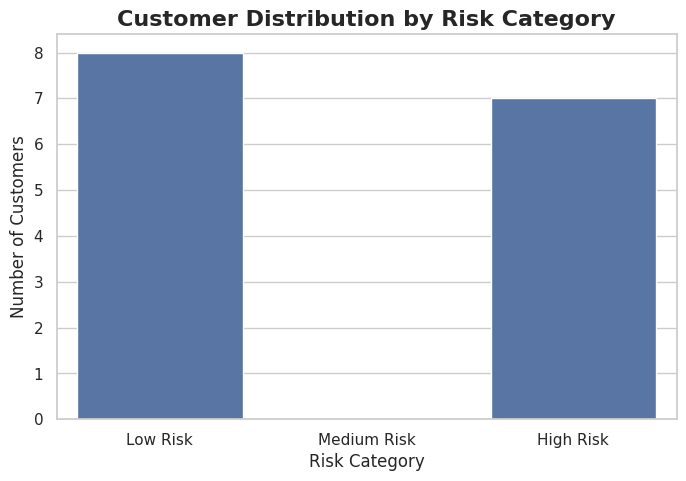

In [25]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='RiskCategory', order=['Low Risk', 'Medium Risk', 'High Risk'])
plt.title('Customer Distribution by Risk Category', fontsize=16, fontweight='bold')
plt.xlabel('Risk Category')
plt.ylabel('Number of Customers')
plt.show()

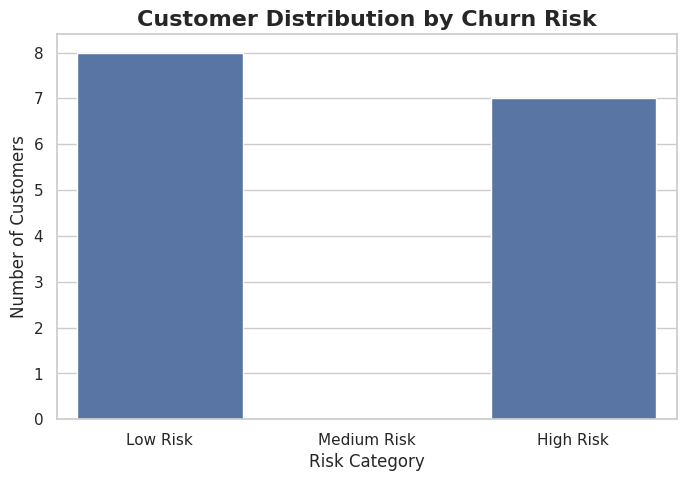

In [22]:
plt.figure(figsize=(8, 5))

risk_order = [
    "Low Risk",
    "Medium Risk",
    "High Risk"
]

sns.countplot(
    data=df,
    x="RiskCategory",
    order=risk_order
)

plt.title(
    "Customer Distribution by Churn Risk",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Risk Category")
plt.ylabel("Number of Customers")

plt.show()

In [23]:
risk_churn = pd.crosstab(
    df["RiskCategory"],
    df["Churn"],
    normalize="index"
) * 100

risk_churn.round(2)

Churn,No,Yes
RiskCategory,,
High Risk,0.0,100.0
Low Risk,100.0,0.0


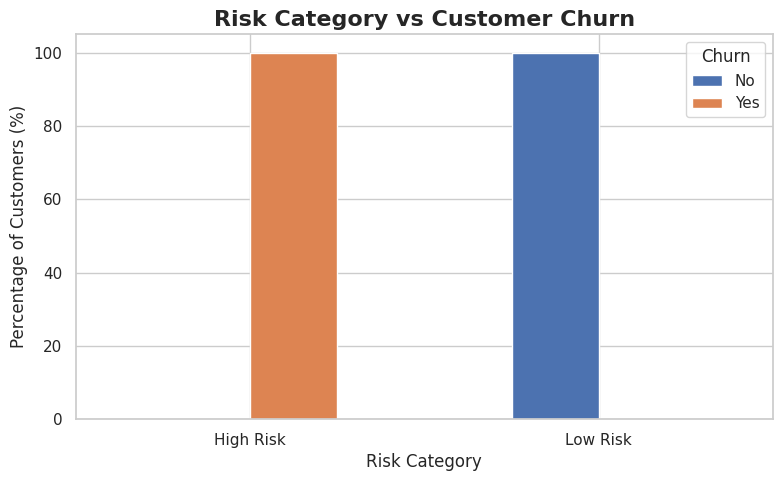

In [24]:
risk_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title(
    "Risk Category vs Customer Churn",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Risk Category")
plt.ylabel("Percentage of Customers (%)")

plt.xticks(rotation=0)

plt.legend(title="Churn")

plt.show()

In [27]:
def identify_risk_factors(row):

    factors = []

    if row["ContractType"] == "Month-to-month":
        factors.append("Month-to-month contract")

    if row["TenureMonths"] <= 12:
        factors.append("Short tenure")

    if row["SupportTickets"] >= 3:
        factors.append("High support tickets")

    if row["MonthlyCharges"] > high_charge_threshold:
        factors.append("High monthly charges")

    if row["PaymentMethod"] in high_risk_payment_methods:
        factors.append("Higher-risk payment method")

    if len(factors) == 0:
        return "No major risk factors"

    return ", ".join(factors)


df["RiskFactors"] = df.apply(
    identify_risk_factors,
    axis=1
)

df[[
    "CustomerID",
    "RiskScore",
    "RiskCategory",
    "RiskFactors"
]]

,CustomerID,RiskScore,RiskCategory,RiskFactors
0,CUST-1001,8,High Risk,"Short tenure, High support tickets"
1,CUST-1002,1,Low Risk,No major risk factors
2,CUST-1003,9,High Risk,"Short tenure, High support tickets, Higher-ris..."
3,CUST-1004,1,Low Risk,High monthly charges
4,CUST-1005,9,High Risk,"Short tenure, High support tickets, Higher-ris..."
5,CUST-1006,2,Low Risk,Higher-risk payment method
6,CUST-1007,8,High Risk,"Short tenure, High support tickets"
7,CUST-1008,1,Low Risk,High monthly charges
8,CUST-1009,1,Low Risk,No major risk factors
9,CUST-1010,9,High Risk,"Short tenure, High support tickets, Higher-ris..."


# Customer Retention Recommendations

The next step is to translate risk factors into actionable
business recommendations.

Examples:

### Month-to-month contract
Recommendation:
Offer a longer-term contract with an attractive retention incentive.

### Short tenure
Recommendation:
Provide onboarding support and early-stage engagement campaigns.

### High support tickets
Recommendation:
Contact the customer and resolve recurring service issues.

### High monthly charges
Recommendation:
Review plan value and offer a suitable lower-cost or better-value plan.

### Payment method risk
Recommendation:
Offer convenient alternative payment methods or payment assistance.

The objective is to make the model actionable rather than simply
identifying high-risk customers.

In [29]:
def generate_recommendation(row):

    recommendations = []

    if row["ContractType"] == "Month-to-month":
        recommendations.append(
            "Offer a longer-term contract with a retention incentive"
        )

    if row["TenureMonths"] <= 12:
        recommendations.append(
            "Provide onboarding and early engagement support"
        )

    if row["SupportTickets"] >= 3:
        recommendations.append(
            "Contact customer and resolve support issues"
        )

    if row["MonthlyCharges"] > high_charge_threshold:
        recommendations.append(
            "Review plan value and consider a better-value offer"
        )

    if row["PaymentMethod"] in high_risk_payment_methods:
        recommendations.append(
            "Offer alternative or more convenient payment options"
        )

    if len(recommendations) == 0:
        return "Continue regular customer engagement"

    return " | ".join(recommendations)


df["Recommendation"] = df.apply(
    generate_recommendation,
    axis=1
)

In [31]:
customer_risk_table = df[[
    "CustomerID",
    "SegmentName",
    "ContractType",
    "TenureMonths",
    "PaymentMethod",
    "MonthlyCharges",
    "SupportTickets",
    "Churn",
    "RiskScore",
    "RiskCategory",
    "RiskFactors",
    "Recommendation"
]].sort_values(
    by="RiskScore",
    ascending=False
)

customer_risk_table

,CustomerID,SegmentName,ContractType,TenureMonths,PaymentMethod,MonthlyCharges,SupportTickets,Churn,RiskScore,RiskCategory,RiskFactors,Recommendation
2,CUST-1003,Established Customers,Month-to-Month,6,UPI,49.99,5,Yes,9,High Risk,"Short tenure, High support tickets, Higher-ris...",Provide onboarding and early engagement suppor...
4,CUST-1005,High Engagement / High Support,Month-to-Month,8,Debit Card,79.99,4,Yes,9,High Risk,"Short tenure, High support tickets, Higher-ris...",Provide onboarding and early engagement suppor...
9,CUST-1010,Established Customers,Month-to-Month,4,UPI,49.99,4,Yes,9,High Risk,"Short tenure, High support tickets, Higher-ris...",Provide onboarding and early engagement suppor...
13,CUST-1014,Established Customers,Month-to-Month,2,UPI,49.99,5,Yes,9,High Risk,"Short tenure, High support tickets, Higher-ris...",Provide onboarding and early engagement suppor...
0,CUST-1001,High Engagement / High Support,Month-to-Month,12,Credit Card,49.99,3,Yes,8,High Risk,"Short tenure, High support tickets",Provide onboarding and early engagement suppor...
6,CUST-1007,Established Customers,Month-to-Month,3,Credit Card,49.99,6,Yes,8,High Risk,"Short tenure, High support tickets",Provide onboarding and early engagement suppor...
11,CUST-1012,High Engagement / High Support,Month-to-Month,14,Debit Card,79.99,3,Yes,7,High Risk,"High support tickets, Higher-risk payment method",Contact customer and resolve support issues | ...
5,CUST-1006,High Engagement / High Support,One Year,18,UPI,49.99,2,No,2,Low Risk,Higher-risk payment method,Offer alternative or more convenient payment o...
1,CUST-1002,High Engagement / High Support,One Year,24,Bank Transfer,79.99,1,No,1,Low Risk,No major risk factors,Continue regular customer engagement
3,CUST-1004,New / Low Engagement,Two Year,36,Credit Card,149.99,0,No,1,Low Risk,High monthly charges,Review plan value and consider a better-value ...


In [32]:
high_priority = customer_risk_table[
    customer_risk_table["RiskCategory"] == "High Risk"
]

high_priority

,CustomerID,SegmentName,ContractType,TenureMonths,PaymentMethod,MonthlyCharges,SupportTickets,Churn,RiskScore,RiskCategory,RiskFactors,Recommendation
2,CUST-1003,Established Customers,Month-to-Month,6,UPI,49.99,5,Yes,9,High Risk,"Short tenure, High support tickets, Higher-ris...",Provide onboarding and early engagement suppor...
4,CUST-1005,High Engagement / High Support,Month-to-Month,8,Debit Card,79.99,4,Yes,9,High Risk,"Short tenure, High support tickets, Higher-ris...",Provide onboarding and early engagement suppor...
9,CUST-1010,Established Customers,Month-to-Month,4,UPI,49.99,4,Yes,9,High Risk,"Short tenure, High support tickets, Higher-ris...",Provide onboarding and early engagement suppor...
13,CUST-1014,Established Customers,Month-to-Month,2,UPI,49.99,5,Yes,9,High Risk,"Short tenure, High support tickets, Higher-ris...",Provide onboarding and early engagement suppor...
0,CUST-1001,High Engagement / High Support,Month-to-Month,12,Credit Card,49.99,3,Yes,8,High Risk,"Short tenure, High support tickets",Provide onboarding and early engagement suppor...
6,CUST-1007,Established Customers,Month-to-Month,3,Credit Card,49.99,6,Yes,8,High Risk,"Short tenure, High support tickets",Provide onboarding and early engagement suppor...
11,CUST-1012,High Engagement / High Support,Month-to-Month,14,Debit Card,79.99,3,Yes,7,High Risk,"High support tickets, Higher-risk payment method",Contact customer and resolve support issues | ...


In [33]:
risk_revenue = (
    df.groupby("RiskCategory")["MonthlyCharges"]
    .sum()
    .reindex([
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ])
    .reset_index()
)

risk_revenue

,RiskCategory,MonthlyCharges
0,Low Risk,859.92
1,Medium Risk,NaN
2,High Risk,409.93


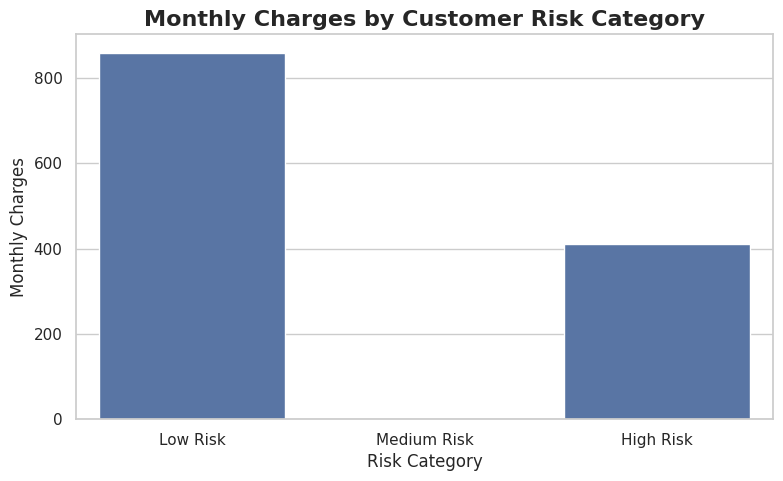

In [34]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=risk_revenue,
    x="RiskCategory",
    y="MonthlyCharges",
    order=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

plt.title(
    "Monthly Charges by Customer Risk Category",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Risk Category")
plt.ylabel("Monthly Charges")

plt.show()

In [35]:
segment_risk = pd.crosstab(
    df["SegmentName"],
    df["RiskCategory"]
)

segment_risk

RiskCategory,High Risk,Low Risk
SegmentName,,
Established Customers,4,0
High Engagement / High Support,3,4
New / Low Engagement,0,4


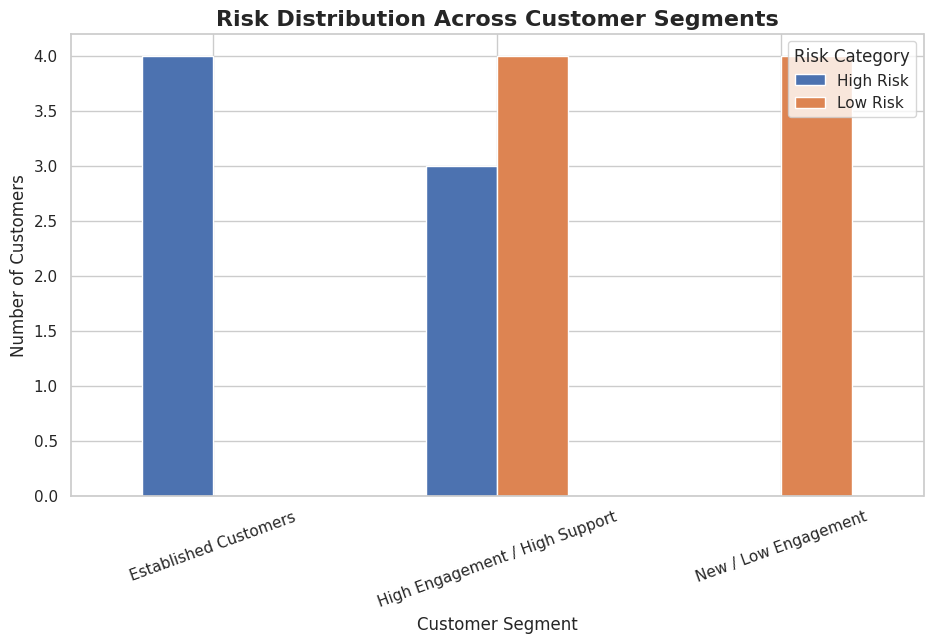

In [36]:
segment_risk.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title(
    "Risk Distribution Across Customer Segments",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.legend(title="Risk Category")

plt.show()

In [37]:
priority_table = df[[
    "CustomerID",
    "SegmentName",
    "RiskScore",
    "RiskCategory",
    "MonthlyCharges",
    "Churn",
    "RiskFactors",
    "Recommendation"
]].copy()

priority_order = {
    "High Risk": 1,
    "Medium Risk": 2,
    "Low Risk": 3
}

priority_table["RiskPriority"] = (
    priority_table["RiskCategory"]
    .map(priority_order)
)

priority_table = priority_table.sort_values(
    by=["RiskPriority", "RiskScore", "MonthlyCharges"],
    ascending=[True, False, False]
)

priority_table.drop(
    columns=["RiskPriority"]
)

,CustomerID,SegmentName,RiskScore,RiskCategory,MonthlyCharges,Churn,RiskFactors,Recommendation
4,CUST-1005,High Engagement / High Support,9,High Risk,79.99,Yes,"Short tenure, High support tickets, Higher-ris...",Provide onboarding and early engagement suppor...
2,CUST-1003,Established Customers,9,High Risk,49.99,Yes,"Short tenure, High support tickets, Higher-ris...",Provide onboarding and early engagement suppor...
9,CUST-1010,Established Customers,9,High Risk,49.99,Yes,"Short tenure, High support tickets, Higher-ris...",Provide onboarding and early engagement suppor...
13,CUST-1014,Established Customers,9,High Risk,49.99,Yes,"Short tenure, High support tickets, Higher-ris...",Provide onboarding and early engagement suppor...
0,CUST-1001,High Engagement / High Support,8,High Risk,49.99,Yes,"Short tenure, High support tickets",Provide onboarding and early engagement suppor...
6,CUST-1007,Established Customers,8,High Risk,49.99,Yes,"Short tenure, High support tickets",Provide onboarding and early engagement suppor...
11,CUST-1012,High Engagement / High Support,7,High Risk,79.99,Yes,"High support tickets, Higher-risk payment method",Contact customer and resolve support issues | ...
5,CUST-1006,High Engagement / High Support,2,Low Risk,49.99,No,Higher-risk payment method,Offer alternative or more convenient payment o...
3,CUST-1004,New / Low Engagement,1,Low Risk,149.99,No,High monthly charges,Review plan value and consider a better-value ...
7,CUST-1008,New / Low Engagement,1,Low Risk,149.99,No,High monthly charges,Review plan value and consider a better-value ...


In [38]:
df.to_csv(
    "customer_churn_task04_results.csv",
    index=False
)

print("Task 04 results successfully exported.")

Task 04 results successfully exported.


In [39]:
from google.colab import files

files.download("customer_churn_task04_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Business Insights

## Customer Segmentation

K-Means clustering was used to divide customers into three groups
based on age, tenure, monthly charges, and support-ticket activity.

The resulting segments were interpreted according to their average
customer characteristics.

## Churn Risk

An explainable rule-based risk score was developed using factors such
as contract type, tenure, support-ticket volume, monthly charges, and
payment method.

Customers were categorized into:

- Low Risk
- Medium Risk
- High Risk

## Risk Explanation

The model provides the specific factors contributing to each customer's
risk score, making the output easier for business users to understand.

## Recommendations

Customer-specific retention recommendations were generated based on
the observed risk factors.

Examples include:

- Offering longer-term contracts
- Improving onboarding
- Resolving support issues
- Reviewing high-cost plans
- Providing alternative payment options

## Business Value

The combined segmentation and risk analysis allows the business to
move from simply measuring churn to identifying customers who may
require targeted retention actions.

## Important Limitation

The dataset contains only a small number of synthetic customers.
Therefore, the segmentation and risk scores are demonstrative and
should not be treated as statistically validated predictions.

A larger real-world dataset would be required before using this
approach for operational customer-retention decisions.